# Cancer genes: one complete CPDB graph

Follow six steps: open your saved project → inspect the real graph and original label masks → change and save experiment settings → review the files and exact command → run the saved script → plot actual scores.

This is a **three-iteration process demo**, not a clinical tool, eight-network benchmark, or paper artifact. Cancer is outside the paper's four experiments. The complete CPDB graph stays intact; only the original Train and Validation labels participate in development. Test labels are not loaded. **Recorded example:** this notebook now shows the real CPDB preview and measured Formal scores from a completed three-iteration run. See the [example and provenance](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/cancer/example/README.md). Initialization clears these archived outputs in your own project; your run generates its own results.

Use the [Cancer setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/cancer/README.md). Before paid execution, use the [hardware check](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md): one supported NVIDIA GPU, working monitoring, and room for the saved allowance (initially 10 GiB). CPU training is unsupported. CPDB occupies 1.50 GB on disk; one CPU loader audit peaked near 980 MiB RAM, which is an observation, not a training RAM minimum. Keep additional space for environments and results. Reducing label fractions does **not** reduce full-graph memory or message passing.


## 1. Open the saved project

Follow the [Cancer setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/cancer/README.md) for installation and initialization; shared paths are explained in the [directory guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/README.md#source-project-data-and-run-directories).

Download the **CPDB file only** (about 1.50 GB) before running cells:

```bash
export CANCER_DATA="/absolute/path/data/cancer"
mkdir -p "$CANCER_DATA/cpdb"
curl --fail --location --output "$CANCER_DATA/cpdb/data.h5" \
  'https://huggingface.co/datasets/FrontisAI/NatureBench/resolve/9e6a69f10865dd56f4991b49d1c974e2006b6b18/tasks/s41551-024-01312-5/problem/data/cpdb/data.h5?download=true'
```

Initialize with `--data-dir "$CANCER_DATA"`, the directory containing `cpdb/`. This is saved in `experiments/cancer-demo.json`; no second prepared-data directory is needed. The data preview checks file size and graph/mask structure, while launch verifies the complete source file. Fix any data error before continuing. Keep the successful download for subsequent runs; `RUN_QUICK_DEMO=False` still reads the graph for preview.

Your initialized project contains:

```text
project/
  project.json
  tasks/cancer/compositions/cpdb_tutorial.yaml
  tasks/cancer/declared/                # CPDB description, shape and source identity
  tasks/cancer/plugins/                 # Original graph, metric, model and loss owners
  experiments/cancer-demo.json          # Fractions, iterations, budgets and output path
  experiments/workflow.json             # Native fixed workflow treatment
  llm/agents.json                       # Luna routes; no keys here
  scripts/run-cancer.sh                 # Launches the saved JSON
  notebooks/cancer_tutorial.ipynb        # This copied notebook
  runs/cancer_demo_001/                 # Created by a real launch
  plots/                               # PNG, SVG and score CSV
```

The data root is separate and contains `cpdb/data.h5`. Nothing is copied back into either repository. `SELECTED_EXPERIMENT="cancer-demo"` selects the initial `cancer-demo.json` and `run-cancer.sh`; a named variant selects its own JSON, script and workspace. Open the copied notebook with this exp checkout's Jupyter kernel.


In [ ]:
import json
import os
import sys
from pathlib import Path

home = os.environ.get("TUTORIAL_HOME")
if not home:
    raise RuntimeError(
        "Export TUTORIAL_HOME to your initialized external project and restart Jupyter."
    )
PROJECT = Path(home).expanduser().resolve()
if not (PROJECT / "project.json").is_file():
    raise RuntimeError(
        "Missing project.json; initialize a new external Cancer project using the README."
    )
binding = json.loads((PROJECT / "project.json").read_text())
EXP_CHECKOUT = Path(binding["exp_checkout"])
if Path(sys.prefix).resolve() != (EXP_CHECKOUT / ".venv").resolve():
    raise RuntimeError(
        "Select the SIDERIUS Cancer tutorial kernel from this exp checkout."
    )
sys.dont_write_bytecode = True
os.chdir(EXP_CHECKOUT)
from IPython.display import Markdown, display

from tutorials.supplementary.cancer.data import scope_counts, show_graph
from tutorials.supplementary.cancer.demo import plot_results, review, run_demo
from tutorials.supplementary.cancer.project import save_variant
from tutorials.supplementary.cancer.settings import CancerExperiment

SELECTED_EXPERIMENT = "cancer-demo"  # Or your saved variant name.
EXPERIMENT = PROJECT / "experiments" / f"{SELECTED_EXPERIMENT}.json"
SCRIPT = (
    PROJECT
    / "scripts"
    / (
        "run-cancer.sh"
        if SELECTED_EXPERIMENT == "cancer-demo"
        else f"run-{SELECTED_EXPERIMENT}.sh"
    )
)
settings = CancerExperiment.model_validate_json(EXPERIMENT.read_text())
print(
    f"Project: {PROJECT}\nExperiment: {EXPERIMENT}\nScript: {SCRIPT}\nRaw data: {settings.data_dir}\nFresh run workspace: {settings.workspace}"
)

## 2. Inspect the graph and active labels

One sample is **the entire CPDB network**, not one gene. Original data has 13,627 nodes with 64 features each. The task packs nodes and non-self directed edges into `[518005, 68]`. Columns 0–3 are node marker, source, destination and active-label marker; columns 4–67 hold node features. Node and edge records remain present when a label fraction changes. Native batch size is exactly 1.

The supplied masks contain 2,013 Train, 224 Validation and 746 Test nodes. They are disjoint. This is transductive learning: every node's features and graph connections are visible, including unlabelled nodes; only active Train labels contribute to training loss. Validation scores feed the search. Test labels are not loaded or scored.

The next cell uses the actual task loader. Counts and class counts are for **seed 42 only**, not proof of later attempts' class support. The pictures show Train features and a topology crop **for visualization only**; training still receives the complete graph.


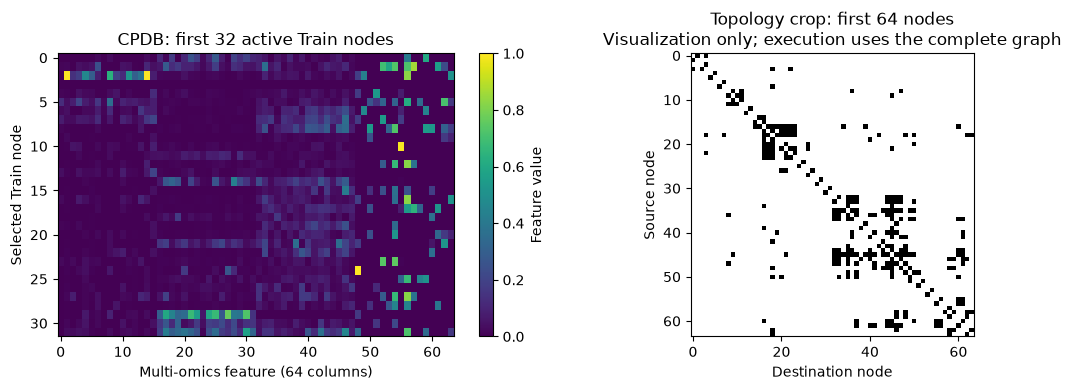

In [ ]:
settings = CancerExperiment.model_validate_json(EXPERIMENT.read_text())
counts = scope_counts(settings)
rows = "\n".join(
    f"| {c.name} | {c.label_fraction:g} | {c.graphs} | {c.nodes} | {c.records} | {c.active_labels} | {c.negative} | {c.positive} |"
    for c in counts
)
display(
    Markdown(
        "| Seed 42 scope | Label fraction | Graphs | Nodes | Packed records | Active labels | Negative | Positive |\n|---|---|---|---|---|---|---|---|\n"
        + rows
    )
)
figure = show_graph(settings)
display(figure)

## 3. Change and save an experiment

The copied task package defines graph packing, original masks, structured outputs, masked BCE loss and `mean_auprc` (higher is better). The experiment defines how long and how many times to search, the active-label fractions, model routes and output location. Keep `cpdb_tutorial.yaml` on CPDB with `evaluation_split: val`. The other original network compositions are separate experiments, not switches this tutorial implements.

| Saved JSON field | Default | Meaning |
|---|---:|---|
| `iterations` | 3 | Number of native search iterations |
| `rounds` | 2 | Native tuning-round ceiling; at least 2 |
| `epochs` | 1 | Epoch ceiling in Trial and Formal |
| `trial_train_label_fraction` / `formal_train_label_fraction` | 1 / 1 | Fraction of original Train labels supervised in each phase |
| `trial_eval_label_fraction` / `formal_eval_label_fraction` | 1 / 1 | Fraction of original Validation labels scored |
| `trial_minutes` / `formal_minutes` | 2 / 5 | Per-phase training time allowances, not whole-run duration |
| `vram_gib` | 10 | Shared VRAM allowance; stage overrides are optional |
| `gpu` | null | Selected visible GPU; optional name expectation |

Fractions must be between 0.01 and 1. For example, `trial_train_label_fraction=0.25` selects 504 of 2,013 Train labels, while `trial_eval_label_fraction=0.25` selects 56 of 224 Validation labels. **The graph remains `[518005, 68]`.** Small validation subsets may lack both classes and cannot be scored; the defaults therefore use the full validation mask. Do not present a smaller label fraction as a memory-saving graph sampler.

Try one change at a time in `CHANGES`:

```python
{"iterations": 4}
{"trial_train_label_fraction": 0.25, "formal_train_label_fraction": 1.0}
{"trial_eval_label_fraction": 0.25, "formal_eval_label_fraction": 1.0}
{"trial_minutes": 3, "formal_minutes": 6, "vram_gib": 12.0}
```

`SAVE_VARIANT=True` writes a new JSON and shell script. Reusing a variant name refuses rather than overwriting. After saving once, set `SAVE_VARIANT=False`, set `SELECTED_EXPERIMENT="cancer-four-001"` (or your chosen name) in section 1, and rerun from section 1. This selects the new JSON and its matching script. Continuing directly after the save cell still uses the previously selected experiment. Batch size remains exactly 1 and is not a tuning knob. Native routing calls this structured float-output contract `regressor`; the scientific problem is binary node classification and the loss remains masked BCE.


In [ ]:
SAVE_VARIANT = False
VARIANT_NAME = "cancer-four-001"
CHANGES = {"iterations": 4}
if SAVE_VARIANT:
    new_experiment, new_script = save_variant(
        PROJECT, EXPERIMENT, name=VARIANT_NAME, changes=CHANGES
    )
    print(
        f"Saved: {new_experiment}\nScript: {new_script}\nSelect {VARIANT_NAME!r} in section 1 before running it."
    )
else:
    print("Using the selected saved JSON unchanged. Save-as is disabled.")

## 4. Review the exact saved files before running

Inspect the paths and **saved values** printed below. Check the CPDB composition, `declared/tutorial_source_files.json`, `declared/tutorial_task_config.yaml`, workflow, `llm/agents.json`, selected experiment JSON and its matching script. Edit only your copied files. There is no active human-advice file, Data Analysis or literature-review role in this treatment.

Run the hardware-only command from the exp checkout, substituting the exact selected JSON printed below:

```bash
.venv/bin/python -m tutorials.shared.hardware --experiment /absolute/project/experiments/cancer-demo.json
```

It needs no API key and starts no training; it queries the GPU and executes a tiny kernel. Passing checks current occupied VRAM plus your allowance against capacity/quota. It is not a reservation or proof that a future model fits. RAM/disk outputs are observations, not unknown workload guarantees.

The next preview invokes the saved script without `--launch`; it has no provider or GPU effects. Preview checks size and mask structure; it does not verify the complete source file. Launch verifies that file, keys and hardware. An existing output workspace skips this fresh-launch preview so section 5 can verify completed-result reuse.


In [ ]:
display(Markdown(review(EXPERIMENT, SCRIPT)))
RUN_NATIVE_PREVIEW = True
preview_settings = CancerExperiment.model_validate_json(EXPERIMENT.read_text())
if RUN_NATIVE_PREVIEW and preview_settings.workspace.exists():
    print(
        "Workspace exists: native launch preview skipped. Section 5 checks completed-result reuse; section 6 plots records independently."
    )
elif RUN_NATIVE_PREVIEW:
    import subprocess

    subprocess.run(["bash", str(SCRIPT)], check=True)
else:
    print("Native preview skipped; this is not launch qualification.")

## 5. Run the saved script — API and GPU effects

**Run All reaches the next cell.** With `RUN_QUICK_DEMO=True`, it delegates to the exact saved shell script and runs the three-iteration native workflow. Set it to `False` for CPU-only inspection. Export your own `OPENAI_API_KEY` before starting Jupyter; do not put keys in notebooks or JSON. The initializer writes the inexpensive all-Luna test routing, not the paper research profile.

Outside Jupyter, the default command is `bash /absolute/project/scripts/run-cancer.sh --launch`; variants use the script printed in section 3. The notebook contains no alternate trainer. Per-phase budgets and the notebook timeout are not an API spending cap. Check provider billing controls before launching.

Completed unchanged runs are reused without a new API call. Changed inputs or an interrupted run require a fresh variant/workspace; never delete evidence to force a rerun. The demo verifies the workflow, not a high score. It declares no Health checks, so a successful execution does not imply Health PASS.


In [ ]:
RUN_QUICK_DEMO = True
NOTEBOOK_TIMEOUT_SECONDS = 3600
if RUN_QUICK_DEMO:
    result = run_demo(EXPERIMENT, SCRIPT, timeout_seconds=NOTEBOOK_TIMEOUT_SECONDS)
    print(result)
else:
    print("Live search disabled: no saved script launched, no API/GPU work.")

## 6. Plot scores actually recorded

The native Formal score is validation `mean_auprc`; for one network it is CPDB average precision. It is not the eight-network benchmark mean and not a final blind Test score. Higher is better, but three iterations need not improve monotonically.

This cell can plot an earlier saved experiment independently of a launch. Replace `PLOT_EXPERIMENT` with its JSON path; output goes to the external project's `plots/` directory. The plot uses the shared paper-style conventions: hollow points for invalid/rejected scored attempts, no invented zero for missing scores. If no scored result exists, it says so. The task has no Health gate; execution validity and scoreability still matter.


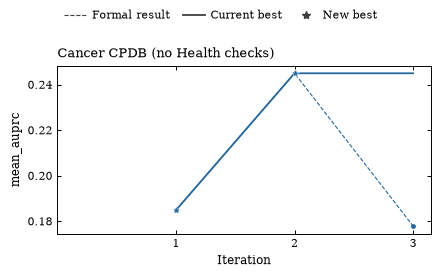

In [ ]:
PLOT_EXPERIMENT = (
    EXPERIMENT  # Or Path("/absolute/project/experiments/earlier-run.json")
)
PLOT_OUTPUT = PROJECT / "plots" / PLOT_EXPERIMENT.stem
plot_settings = CancerExperiment.model_validate_json(PLOT_EXPERIMENT.read_text())
if plot_settings.workspace.is_dir():
    try:
        display(plot_results(PLOT_EXPERIMENT, PLOT_OUTPUT))
        print(f"Saved PNG/SVG/CSV to {PLOT_OUTPUT}")
    except ValueError as error:
        print(f"Plot unavailable: {error}")
else:
    print(
        "No result workspace yet. Run the saved script when authorized, or select an existing PLOT_EXPERIMENT."
    )